In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
import joblib

# Reload the final model + feature data
X_train_final = np.load('../data/X_train_final_30.npy')
X_test_final = np.load('../data/X_test_final_30.npy')
final_feature_names = np.load('../data/final_feature_names_30.npy', allow_pickle=True)

df_train = pd.read_csv('../data/df_train_v2.csv')
df_test = pd.read_csv('../data/df_test_v2.csv')
y_train = df_train['target']
y_test = df_test['target']

# Refit the final model (or load if you saved it)
final_model = LogisticRegression(
    penalty='l2', solver='lbfgs', C=1.0,
    class_weight='balanced', max_iter=1000, random_state=42
)
final_model.fit(X_train_final, y_train)

print(f"Final model trained on {X_train_final.shape}")
print(f"Number of features: {len(final_feature_names)}")

/home/sharon/anaconda3/envs/datacareer/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Final model trained on (78283, 30)
Number of features: 30


In [2]:
# Extract and organize coefficients
coefficients = final_model.coef_[0]

coef_df = pd.DataFrame({
    'feature': final_feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients),
    'odds_ratio': np.exp(coefficients)
}).sort_values('abs_coefficient', ascending=False).reset_index(drop=True)

# Clean up feature names for display
def clean_name(name):
    """Strip transformer prefixes for cleaner display."""
    for prefix in ['num__', 'bin__', 'ord__', 'nom__', 'passthrough_binary__']:
        if name.startswith(prefix):
            return name.replace(prefix, '')
    return name

coef_df['display_name'] = coef_df['feature'].apply(clean_name)

print("All 30 features ranked by coefficient magnitude:")
print(coef_df[['display_name', 'coefficient', 'odds_ratio']].to_string(index=False))

All 30 features ranked by coefficient magnitude:
                display_name  coefficient  odds_ratio
 discharge_disposition_id_22     1.338172    3.812069
  discharge_disposition_id_5     1.010127    2.745949
  discharge_disposition_id_2     0.581477    1.788679
            diag_2_Neoplasms     0.382471    1.465902
  discharge_disposition_id_3     0.382252    1.465582
            number_inpatient     0.362356    1.436710
      diag_1_Musculoskeletal    -0.249156    0.779458
      admission_source_id_17    -0.227423    0.796584
 discharge_disposition_id_18     0.220215    1.246344
    max_glu_serum_not_tested    -0.186979    0.829462
                 diabetesMed     0.172198    1.187913
  discharge_disposition_id_6     0.165408    1.179874
                 glimepiride    -0.165064    0.847839
          payer_code_unknown     0.157011    1.170008
medical_specialty_Cardiology    -0.156733    0.854933
          diag_1_Respiratory    -0.133593    0.874946
                  insulin_No    -

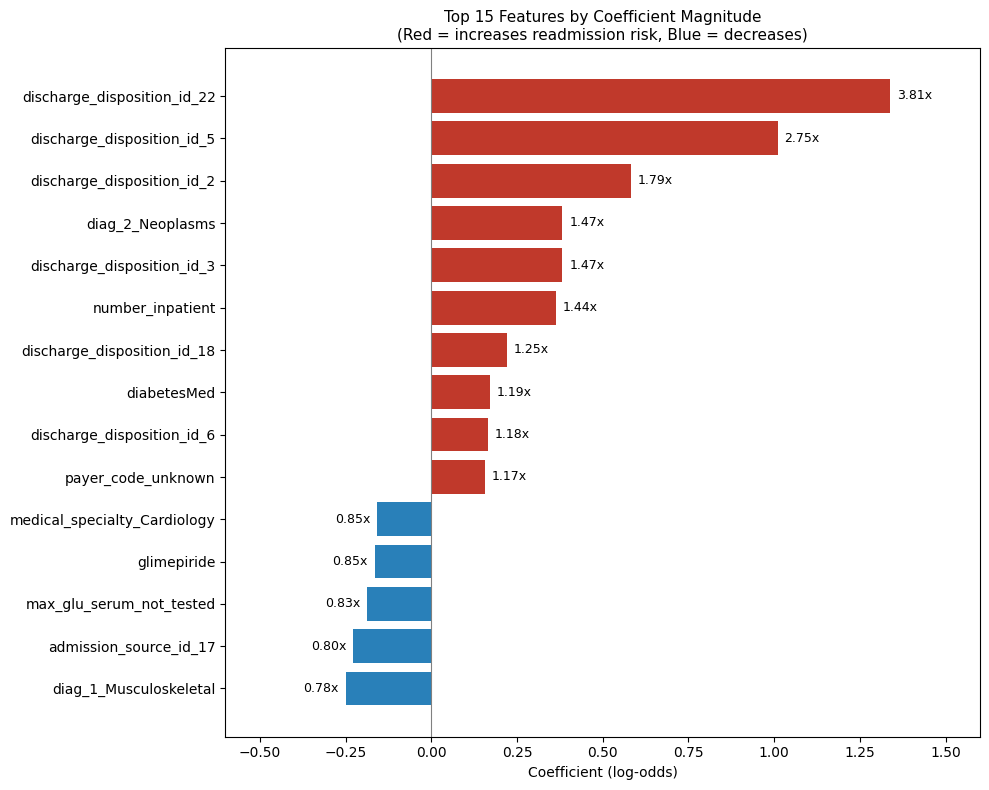

In [3]:
import matplotlib.pyplot as plt

# Top 15 features by absolute coefficient — covers the meaningful ones
top_n = 15
plot_df = coef_df.head(top_n).copy()
plot_df = plot_df.sort_values('coefficient')  # sort for plotting (bottom to top)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#c0392b' if c > 0 else '#2980b9' for c in plot_df['coefficient']]
bars = ax.barh(plot_df['display_name'], plot_df['coefficient'], color=colors)

# Annotate each bar with the odds ratio
for bar, or_val in zip(bars, plot_df['odds_ratio']):
    width = bar.get_width()
    label_x = width + 0.02 if width > 0 else width - 0.02
    ha = 'left' if width > 0 else 'right'
    ax.text(label_x, bar.get_y() + bar.get_height()/2, 
            f'{or_val:.2f}x', va='center', ha=ha, fontsize=9)

ax.axvline(x=0, color='gray', linewidth=0.8)
ax.set_xlabel('Coefficient (log-odds)')
ax.set_title('Top 15 Features by Coefficient Magnitude\n(Red = increases readmission risk, Blue = decreases)', fontsize=11)
ax.set_xlim(-0.6, 1.6)

plt.tight_layout()
plt.savefig('figures/feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

In [4]:
from sklearn.metrics import roc_auc_score

# We need the original demographic columns from df_test (before encoding)
# Predict on test set
y_test_proba = final_model.predict_proba(X_test_final)[:, 1]

# Build a fairness audit dataframe with demographics + predictions + true labels
audit_df = pd.DataFrame({
    'race': df_test['race'].values,
    'gender': df_test['gender'].values,
    'age': df_test['age'].values,
    'y_true': y_test.values,
    'y_proba': y_test_proba
})

print("Audit dataframe created. Subgroup distributions:\n")
print("--- Race ---")
print(audit_df['race'].value_counts())
print(f"\n--- Gender ---")
print(audit_df['gender'].value_counts())
print(f"\n--- Age ---")
print(audit_df['age'].value_counts().sort_index())

Audit dataframe created. Subgroup distributions:

--- Race ---
race
Caucasian          14712
AfricanAmerican     3613
unknown              475
Hispanic             388
Other                251
Asian                100
Name: count, dtype: int64

--- Gender ---
gender
Female    10483
Male       9056
Name: count, dtype: int64

--- Age ---
age
[0-10)         6
[10-20)       94
[20-30)      299
[30-40)      794
[40-50)     1840
[50-60)     3414
[60-70)     4323
[70-80)     4981
[80-90)     3243
[90-100)     545
Name: count, dtype: int64


In [5]:
from sklearn.metrics import roc_auc_score
import numpy as np

def safe_auc(y_true, y_proba, min_positives=30):
    """Compute AUC only if there are enough positives for stability."""
    n_pos = int(y_true.sum())
    n_neg = int((y_true == 0).sum())
    if n_pos < min_positives or n_neg < min_positives:
        return None, n_pos, n_neg
    return roc_auc_score(y_true, y_proba), n_pos, n_neg


def audit_subgroup(df, group_col, min_positives=30):
    """Compute per-subgroup AUC, sample size, and positive rate."""
    results = []
    for group_value in df[group_col].unique():
        subset = df[df[group_col] == group_value]
        auc, n_pos, n_neg = safe_auc(
            subset['y_true'].values,
            subset['y_proba'].values,
            min_positives=min_positives
        )
        results.append({
            'group': group_value,
            'n_total': len(subset),
            'n_positives': n_pos,
            'positive_rate': round(n_pos / len(subset), 4) if len(subset) > 0 else 0,
            'auc': round(auc, 4) if auc is not None else 'too few samples'
        })
    return pd.DataFrame(results).sort_values('n_total', ascending=False)


# Overall reference
overall_auc = roc_auc_score(audit_df['y_true'], audit_df['y_proba'])
print(f"Overall test AUC: {overall_auc:.4f}\n")

print("=" * 60)
print("AUC by RACE:")
print("=" * 60)
print(audit_subgroup(audit_df, 'race').to_string(index=False))

print("\n" + "=" * 60)
print("AUC by GENDER:")
print("=" * 60)
print(audit_subgroup(audit_df, 'gender').to_string(index=False))

print("\n" + "=" * 60)
print("AUC by AGE BRACKET:")
print("=" * 60)
print(audit_subgroup(audit_df, 'age').to_string(index=False))

Overall test AUC: 0.6612

AUC by RACE:
          group  n_total  n_positives  positive_rate             auc
      Caucasian    14712         1757         0.1194          0.6556
AfricanAmerican     3613          459         0.1270          0.6739
        unknown      475           41         0.0863          0.6044
       Hispanic      388           46         0.1186          0.7667
          Other      251           25         0.0996 too few samples
          Asian      100            9         0.0900 too few samples

AUC by GENDER:
 group  n_total  n_positives  positive_rate    auc
Female    10483         1270         0.1211 0.6674
  Male     9056         1067         0.1178 0.6538

AUC by AGE BRACKET:
   group  n_total  n_positives  positive_rate             auc
 [70-80)     4981          641         0.1287          0.6516
 [60-70)     4323          536         0.1240          0.6643
 [50-60)     3414          319         0.0934          0.6602
 [80-90)     3243          416         0